In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
train = pd.read_csv('/content/drive/MyDrive/DataScienceProjects_CommentToxicity/train.csv')
test = pd.read_csv('/content/drive/MyDrive/DataScienceProjects_CommentToxicity/test.csv')


In [3]:
#  Basic sanity Checks

print("Train shape:", train.shape)
print("Teas shape:", test.shape)
print()
print(train.info())
print()
print("Missing values in train:\n", train.isnull().sum())
print()
print("Duplicate comments in train:", train['comment_text'].duplicated().sum())



Train shape: (159571, 8)
Teas shape: (153164, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None

Missing values in train:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Duplicate comments in train: 0


In [4]:
# Understand the Labels(the most important step for this dataset)
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# How much comments have each label = 1
print(train[label_cols].sum())
print()

# What % of total data is each label
print((train[label_cols].sum() / len(train)) * 100)
print()

# How many comments have No label at all (completely clean)
clean_comments = train[(train[label_cols].sum(axis=1) == 0)]
print("Clean (no-toxic) comments:", len(clean_comments))
print("Toxic (at least 1 label) comments:", len(train) - len(clean_comments))




toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

toxic            9.584448
severe_toxic     0.999555
obscene          5.294822
threat           0.299553
insult           4.936361
identity_hate    0.880486
dtype: float64

Clean (no-toxic) comments: 143346
Toxic (at least 1 label) comments: 16225


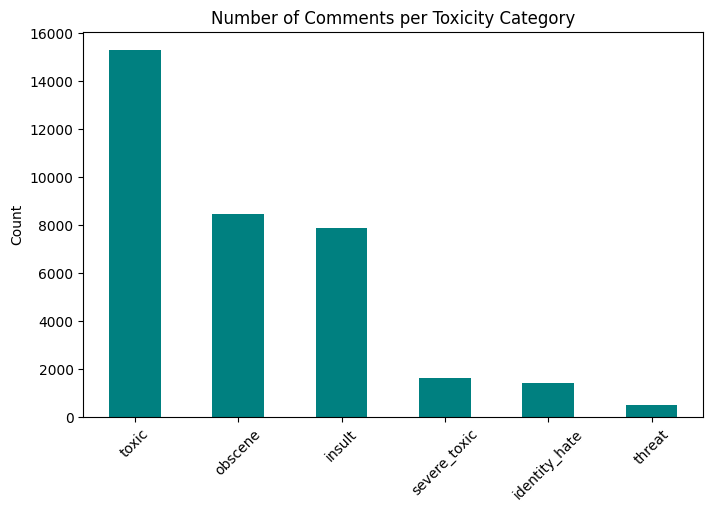

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: text_length, dtype: float64


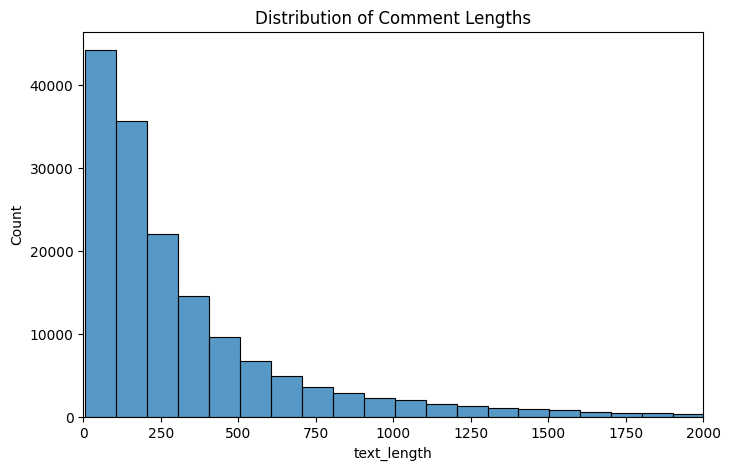

In [5]:
#  Let's Visualize ths + check comment text length
import matplotlib.pyplot as plt
import seaborn as sns

# Plot label distribution
plt.figure(figsize=(8,5))
train[label_cols].sum().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Number of Comments per Toxicity Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Comment length analysis
train['text_length'] = train['comment_text'].apply(len)
print(train['text_length'].describe())

plt.figure(figsize=(8,5))
sns.histplot(train['text_length'], bins=50)
plt.title('Distribution of Comment Lengths')
plt.xlim(0, 2000)
plt.show()


count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: word_count, dtype: float64


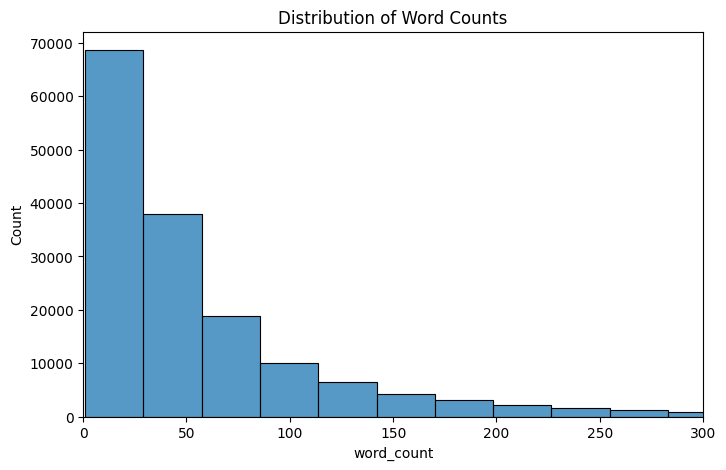

In [6]:
# word count(more relevent for LSTM than character count)
train['word_count'] = train['comment_text'].apply(lambda x: len(x.split()))
print(train['word_count'].describe())

plt.figure(figsize=(8,5))
sns.histplot(train['word_count'], bins=50)
plt.title('Distribution of Word Counts')
plt.xlim(0, 300)
plt.show()


In [7]:
# Text Cleaning
import re

def clean_text(text):
  text = text.lower()
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r'\[\[.*?\]\]', '', text)
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  text = re.sub(r'\S+@\S+', '', text)
  text = re.sub(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', '', text)
  text = re.sub(r'[^a-z\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

train['clean_text'] = train['comment_text'].apply(clean_text)
test['clean_text'] = test['comment_text'].apply(clean_text)

# compare before and after
print("BEFORE:", train['comment_text'].iloc[0][:200])
print()
print("AFTER :", train['clean_text'].iloc[0][:200])



BEFORE: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove th

AFTER : explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the tem


In [8]:
#  check for empty strings after cleaning
empty_after_clean = (train['clean_text'].str.strip() == '').sum()
print("Comments that became empty after cleaning:", empty_after_clean)

#  Check how many were toxic among those (if any)
if empty_after_clean > 0:
  print(train[train['clean_text'].str.strip() == ''][label_cols].sum())





Comments that became empty after cleaning: 32
toxic            2
severe_toxic     0
obscene          1
threat           0
insult           2
identity_hate    0
dtype: int64


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token = "<OOV>")
tokenizer.fit_on_texts(train['clean_text'])

# convert text to sequences of integers
train_sequences = tokenizer.texts_to_sequences(train['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test['clean_text'])

# pad sequences to fixed length
X_train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Sample original text:", train['clean_text'].iloc[0])
print("Sample sequence:", train_sequences[0])
print("Sample padded:", X_train_padded[0])
print("Padded shape:", X_train_padded.shape)


Sample original text: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
Sample sequence: [639, 76, 2, 123, 127, 174, 29, 629, 4522, 11326, 1041, 83, 311, 53, 2011, 10777, 51, 6442, 16, 62, 2606, 144, 8, 2760, 34, 115, 1132, 15131, 2793, 5, 46, 55, 235, 2, 411, 31, 2, 42, 28, 142, 70, 3337, 90]
Sample padded: [  639    76     2   123   127   174    29   629  4522 11326  1041    83
   311    53  2011 10777    51  6442    16    62  2606   144     8  2760
    34   115  1132 15131  2793     5    46    55   235     2   411    31
     2    42    28   142    70  3337    90     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0  

In [10]:
# Train-Validation Split
from sklearn.model_selection import train_test_split

y = train[label_cols].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_padded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (127656, 100)
X_val shape: (31915, 100)
y_train shape: (127656, 6)
y_val shape: (31915, 6)


In [12]:
# Building the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

EMBEDDING_DIM = 128

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,462 (10.18 MB)

 Trainable params: 2,667,462 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# taraing with disconnect protection

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_path = '/content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model.keras'


checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs=5,
    batch_size=128,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6765 - loss: 0.1364
Epoch 1: val_loss improved from None to 0.05032, saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model.keras
998/998 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.8332 - loss: 0.0830 - val_accuracy: 0.9941 - val_loss: 0.0503
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9593 - loss: 0.0503
Epoch 2: val_loss improved from 0.05032 to 0.04886, saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model.keras
998/998 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9637 - loss: 0.0492 - val_accuracy: 0.9941 - val_loss: 0.0489
Epoch 3/5
997/998 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9458 - loss: 0.04

In [14]:
# Proper Evaluation

from sklearn.metrics import roc_auc_score, classification_report

Y_pred_proba = model.predict(X_val)

print("=== AUC-ROC per label ===")
for i, label in enumerate(label_cols):
  auc = roc_auc_score(y_val[:, i], Y_pred_proba[:, i])
  print(f"{label}: {auc:.4f}")

print("\nOverall mean AUC:", roc_auc_score(y_val, Y_pred_proba, average='macro'))

Y_pred_binary = (Y_pred_proba >= 0.5).astype(int)

print("\n=== Classification Report (per label) ===")
print(classification_report(y_val, Y_pred_binary, target_names=label_cols, zero_division=0))


998/998 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
=== AUC-ROC per label ===
toxic: 0.9757
severe_toxic: 0.9888
obscene: 0.9878
threat: 0.9538
insult: 0.9812
identity_hate: 0.9550

Overall mean AUC: 0.9737156590298709

=== Classification Report (per label) ===
               precision    recall  f1-score   support

        toxic       0.87      0.73      0.79      3056
 severe_toxic       0.55      0.22      0.32       321
      obscene       0.83      0.78      0.81      1715
       threat       0.00      0.00      0.00        74
       insult       0.72      0.68      0.70      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.81      0.67      0.73      7074
    macro avg       0.49      0.40      0.44      7074
 weighted avg       0.76      0.67      0.71      7074
  samples avg       0.06      0.06      0.06      7074



In [15]:
#  Lower the classification Threshold

threshold = 0.3
Y_pred_binary_v2 = (Y_pred_proba >= threshold).astype(int)

print(f"=== Classification Report (threshold={threshold}) ===")
print(classification_report(y_val, Y_pred_binary_v2, target_names=label_cols, zero_division=0))


=== Classification Report (threshold=0.3) ===
               precision    recall  f1-score   support

        toxic       0.77      0.83      0.80      3056
 severe_toxic       0.44      0.62      0.51       321
      obscene       0.75      0.85      0.80      1715
       threat       0.00      0.00      0.00        74
       insult       0.64      0.81      0.72      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.71      0.78      0.74      7074
    macro avg       0.43      0.52      0.47      7074
 weighted avg       0.68      0.78      0.73      7074
  samples avg       0.07      0.07      0.07      7074



In [16]:

import tensorflow as tf

# Calculate how imbalanced each label is: (negative count / positive count)
pos_weights = []
for i, label in enumerate(label_cols):
    pos = y_train[:, i].sum()
    neg = len(y_train) - pos
    weight = neg / pos
    pos_weights.append(weight)
    print(f"{label}: pos_weight = {weight:.2f}")

pos_weights = tf.constant(pos_weights, dtype=tf.float32)

def weighted_bce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    # boost the loss when the true label is 1 (positive/toxic) for rare classes
    weight_vector = y_true * pos_weights + (1 - y_true)
    return tf.reduce_mean(weight_vector * bce)



toxic: pos_weight = 9.43
severe_toxic: pos_weight = 99.20
obscene: pos_weight = 17.96
threat: pos_weight = 314.98
insult: pos_weight = 19.38
identity_hate: pos_weight = 113.90


In [17]:

model2 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='sigmoid')
])

model2.compile(
    loss=weighted_bce,
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_path_v2 = '/content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model_v2.keras'
checkpoint2 = ModelCheckpoint(checkpoint_path_v2, monitor='val_loss', save_best_only=True, verbose=1)
early_stop2 = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    callbacks=[checkpoint2, early_stop2]
)


Epoch 1/5
995/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5299 - loss: 0.7601
Epoch 1: val_loss improved from None to 0.42097, saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model_v2.keras
998/998 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7254 - loss: 0.5617 - val_accuracy: 0.9941 - val_loss: 0.4210
Epoch 2/5
995/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9191 - loss: 0.3701
Epoch 2: val_loss improved from 0.42097 to 0.39160, saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model_v2.keras
998/998 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9360 - loss: 0.3685 - val_accuracy: 0.9941 - val_loss: 0.3916
Epoch 3/5
996/998 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9692 

In [18]:

y_pred_proba_v2 = model2.predict(X_val)

print("=== AUC-ROC per label (Model 2) ===")
for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_val[:, i], y_pred_proba_v2[:, i])
    print(f"{label}: {auc:.4f}")

print("\nOverall mean AUC:", roc_auc_score(y_val, y_pred_proba_v2, average='macro'))

# Try threshold 0.5 first since class weighting already compensates for imbalance
y_pred_binary_v2_t5 = (y_pred_proba_v2 >= 0.5).astype(int)
print("\n=== Classification Report (Model 2, threshold=0.5) ===")
print(classification_report(y_val, y_pred_binary_v2_t5, target_names=label_cols, zero_division=0))



998/998 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
=== AUC-ROC per label (Model 2) ===
toxic: 0.9617
severe_toxic: 0.9877
obscene: 0.9826
threat: 0.9694
insult: 0.9759
identity_hate: 0.9589

Overall mean AUC: 0.9727099755085931

=== Classification Report (Model 2, threshold=0.5) ===
               precision    recall  f1-score   support

        toxic       0.65      0.85      0.74      3056
 severe_toxic       0.16      0.96      0.27       321
      obscene       0.53      0.93      0.68      1715
       threat       0.02      0.96      0.05        74
       insult       0.47      0.92      0.62      1614
identity_hate       0.08      0.90      0.15       294

    micro avg       0.35      0.89      0.50      7074
    macro avg       0.32      0.92      0.42      7074
 weighted avg       0.53      0.89      0.64      7074
  samples avg       0.04      0.08      0.05      7074



In [19]:
# fir: per-label optimal threshold

from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

best_thresholds = {}

for i, label in enumerate(label_cols):
  precisions, recalls, thresholds = precision_recall_curve(y_val[:, i], Y_pred_binary_v2[:, i])
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
  best_idx = np.argmax(f1_scores)
  best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
  best_thresholds[label] = best_thresh
  print(f"{label}: best threshold ={best_thresh:.3f}, F1 = {f1_scores[best_idx]:.3f}")

#  Apply thiese custom thresholds

Y_pred_final = np.zeros_like(y_pred_proba_v2)
for i, label in enumerate(label_cols):
  Y_pred_final[:, i] = (y_pred_proba_v2[:, i] >= best_thresholds[label]).astype(int)

print("\n=== Final Classification Report (per-label tuned thresholds) ===")
print(classification_report(y_val, Y_pred_final, target_names=label_cols, zero_division=0))




toxic: best threshold =1.000, F1 = 0.798
severe_toxic: best threshold =1.000, F1 = 0.514
obscene: best threshold =1.000, F1 = 0.799
threat: best threshold =0.000, F1 = 0.005
insult: best threshold =1.000, F1 = 0.717
identity_hate: best threshold =0.000, F1 = 0.018

=== Final Classification Report (per-label tuned thresholds) ===
               precision    recall  f1-score   support

        toxic       0.00      0.00      0.00      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.00      0.00      0.00      1715
       threat       0.00      1.00      0.00        74
       insult       0.00      0.00      0.00      1614
identity_hate       0.01      1.00      0.02       294

    micro avg       0.01      0.05      0.01      7074
    macro avg       0.00      0.33      0.00      7074
 weighted avg       0.00      0.05      0.00      7074
  samples avg       0.01      0.00      0.00      7074



In [20]:
# align the arrays properly

best_thresholds = {}

for i, label in enumerate(label_cols):
    precisions, recalls, thresholds = precision_recall_curve(y_val[:, i], y_pred_proba_v2[:, i])

    # Drop the last precision/recall point — it has no matching threshold
    precisions = precisions[:-1]
    recalls = recalls[:-1]

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]

    best_thresholds[label] = best_thresh
    print(f"{label}: best threshold = {best_thresh:.3f}, F1 = {f1_scores[best_idx]:.3f}")

# Apply these corrected thresholds
y_pred_final = np.zeros_like(y_pred_proba_v2)
for i, label in enumerate(label_cols):
    y_pred_final[:, i] = (y_pred_proba_v2[:, i] >= best_thresholds[label]).astype(int)

print("\n=== Final Classification Report (per-label tuned thresholds) ===")
print(classification_report(y_val, y_pred_final, target_names=label_cols, zero_division=0))



toxic: best threshold = 0.815, F1 = 0.780
severe_toxic: best threshold = 0.962, F1 = 0.512
obscene: best threshold = 0.921, F1 = 0.774
threat: best threshold = 0.969, F1 = 0.157
insult: best threshold = 0.896, F1 = 0.710
identity_hate: best threshold = 0.965, F1 = 0.268

=== Final Classification Report (per-label tuned thresholds) ===
               precision    recall  f1-score   support

        toxic       0.83      0.73      0.78      3056
 severe_toxic       0.44      0.60      0.51       321
      obscene       0.76      0.79      0.77      1715
       threat       0.15      0.16      0.16        74
       insult       0.66      0.77      0.71      1614
identity_hate       0.19      0.45      0.27       294

    micro avg       0.68      0.73      0.71      7074
    macro avg       0.51      0.58      0.53      7074
 weighted avg       0.72      0.73      0.72      7074
  samples avg       0.06      0.06      0.06      7074



In [21]:
# save everything to drive

import pickle

# Save tokenizer
with open('/content/drive/MyDrive/DataScienceProjects/CommentToxicity/tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save best thresholds
with open('/content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_thresholds.pickle', 'wb') as f:
    pickle.dump(best_thresholds, f)

# Model already saved as best_model_v2.keras via checkpoint — confirm it exists
import os
print(os.path.exists('/content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_model_v2.keras'))
print(os.path.exists('/content/drive/MyDrive/DataScienceProjects/CommentToxicity/tokenizer.pickle'))
print(os.path.exists('/content/drive/MyDrive/DataScienceProjects/CommentToxicity/best_thresholds.pickle'))


True
True
True
